# Analysis — N Particles

In [26]:
import matplotlib.pyplot as plt
import numpy as np
np.seterr('warn')

from aux_functions import make_fitting_func, fit_curve, shorten_points, sort_experiments_by_freq
from treament_tcspc_data import fetch_data_filenames, get_fund_freq_and_amp

## Configuração
Edite apenas esta célula para adicionar/remover partículas ou frequências.

In [27]:
filenames_all = fetch_data_filenames("./12-05-26_13-05-26")

In [28]:
def process_npy_array(nparr):
    """Return a list of arrays, where each array is the difference between the current and previous array in nparr. The first array is returned as is."""
    data = []
    non_zero_idx = 0

    for idx in range(len(nparr)):
      if len(nparr[idx][0])>0:
        non_zero_idx = idx
        xs = np.array(nparr[idx][0])
        break

    #Find minimum length
    min_len = len(xs)
    for idx in range(len(nparr)):
      if idx >= non_zero_idx:
        min_len = min(min_len, len(nparr[idx][1]))
    
    xs = xs[:min_len]

    # ys = np.array(nparr[0][1])
    
    for idx in range(len(nparr)):
        if idx>=non_zero_idx:
          if idx == non_zero_idx:
            ys = np.array(nparr[idx][1])[:min_len]
          else:
            ys = np.array(nparr[idx][1])[:min_len]-0*np.array(nparr[idx-1][1])[:min_len]
          # data.append(np.column_stack((xs,ys)))
    
    data = np.column_stack((xs,ys))
        
    # filtered_data =[
    #   array for array in data 
    #   if np.any(array[:, 1] != 0)
    #   ]

    if len(data)>200:
      short_arr = data[:200]
      return short_arr
    
    return data

def extract_data_info_from_path(path: str, raw_data = False):
  freq = int(path.split("_fg")[1].split("Hz")[0])
  amp = float(path.split("Hz_")[1].split("V_")[0])
  offset = float(path.split("V_")[1].split("offs")[0])
  if raw_data:
    data = np.loadtxt(path) if ".txt" in path else np.load(path, allow_pickle=True)
  else:
    data = np.loadtxt(path) if ".txt" in path else process_npy_array(np.load(path, allow_pickle=True))

  return {
      "freq": freq,
      "amp": amp,
      "offset": offset,
      "data": data,
  }

In [29]:
exc_data_npy = [
    extract_data_info_from_path(data_path_npy) for data_path_npy in filenames_all 
    if ("step" in data_path_npy) and (".npy" in data_path_npy) and ("exc_laser" in data_path_npy)
    ]

In [30]:
# freq_list = [1, 10, 100, 1000, 10000]
# filtered_data = [d for d in data_npy if d["freq"] in freq_list]
# filtered_exc_data = [d for d in exc_data_npy if d["freq"] in freq_list]
# exc_data = sort_experiments_by_freq(filtered_exc_data)

In [31]:
#Populate particle list

p_list = []
for p_id in range(10):
    p_list.append({
        "p_label": p_id+1,
        "p_data": [extract_data_info_from_path(p_data_path) for p_data_path in filenames_all if (f"p{p_id+1}_lum" in p_data_path) and ("step" in p_data_path) and (".npy" in p_data_path)]
    })

In [32]:
freq_list = sorted(set([dic["freq"] for dic in exc_data_npy]))

# Layout dos subplots de verificação visual
cols = 4
rows = int(np.ceil(len(freq_list) / cols))
    

## Análise — loop sobre N partículas


  Processing particle 1  


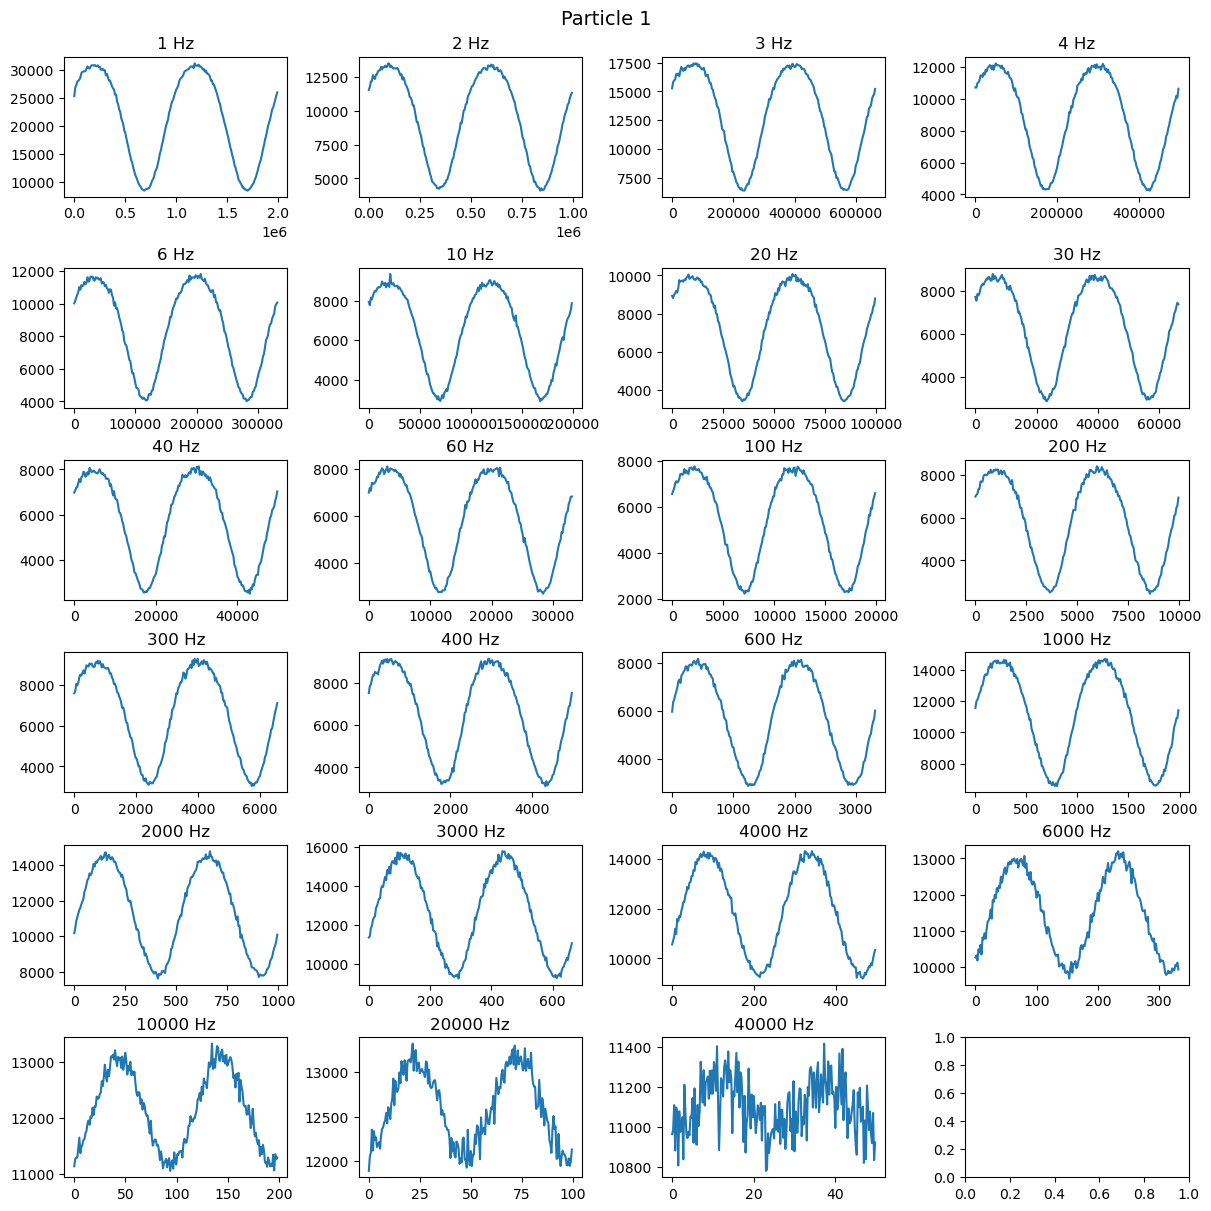


  Processing particle 2  


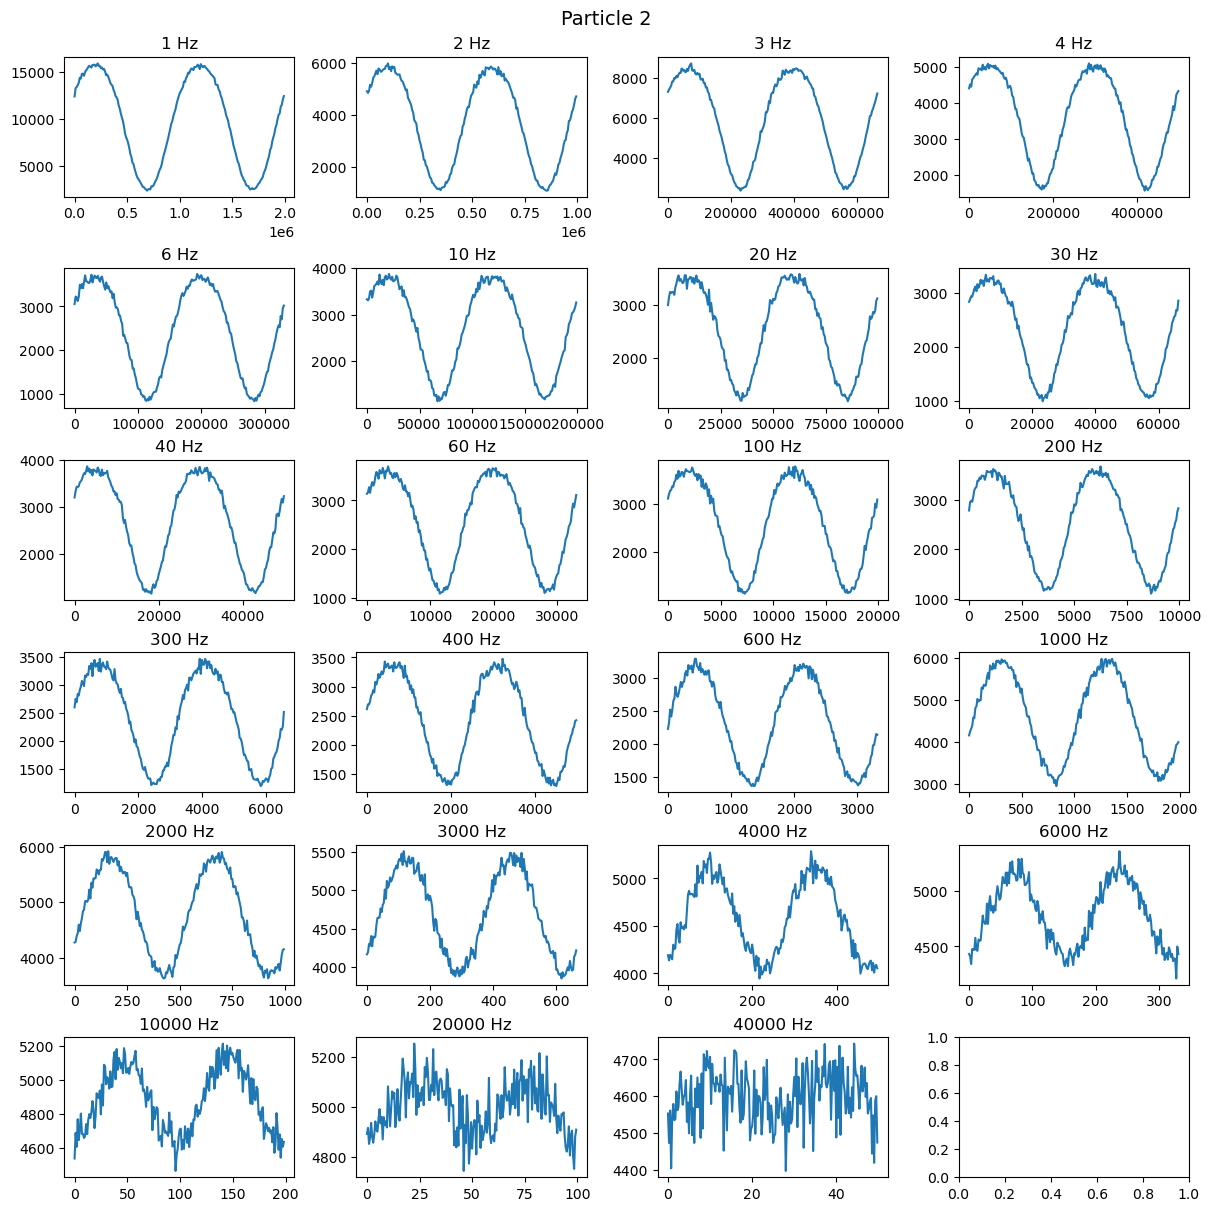


  Processing particle 3  


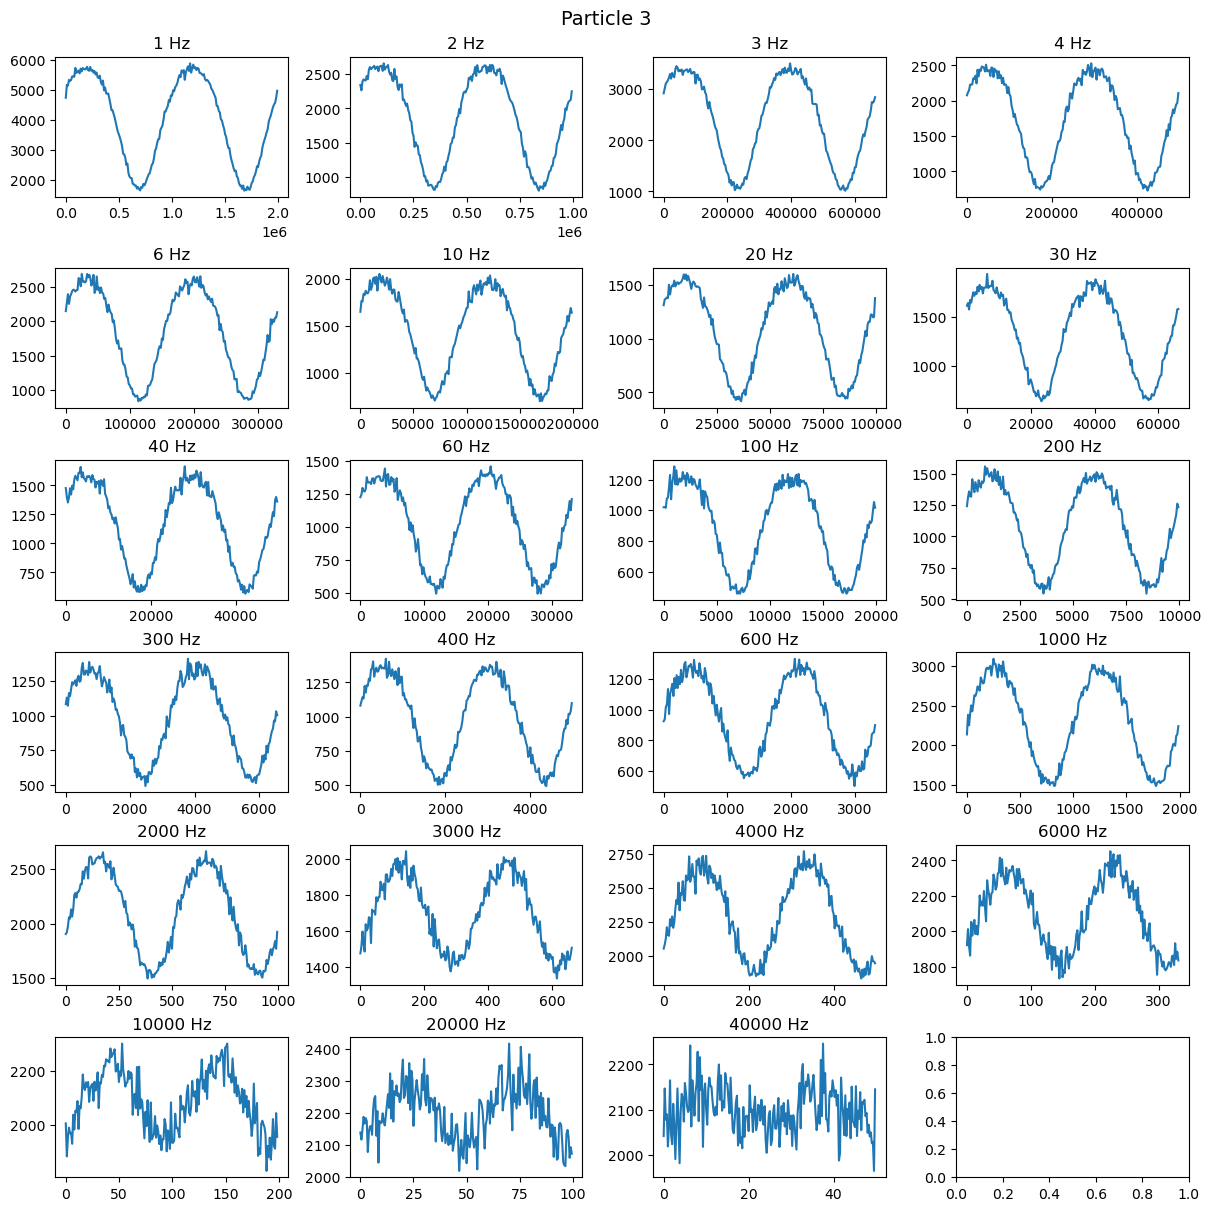


  Processing particle 4  


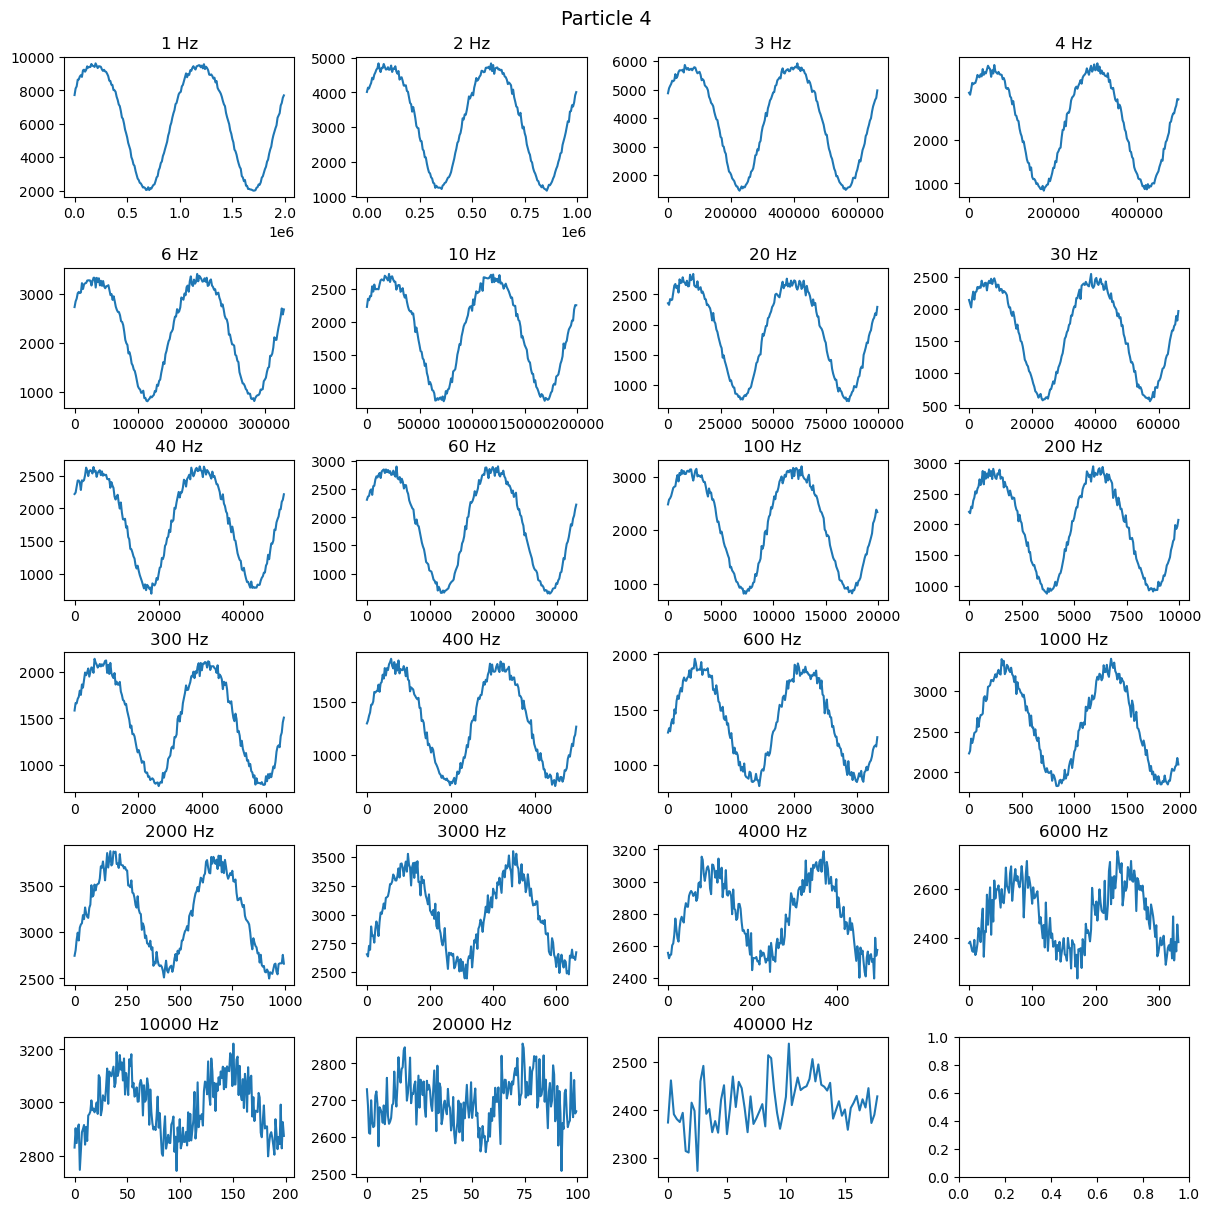


  Processing particle 5  


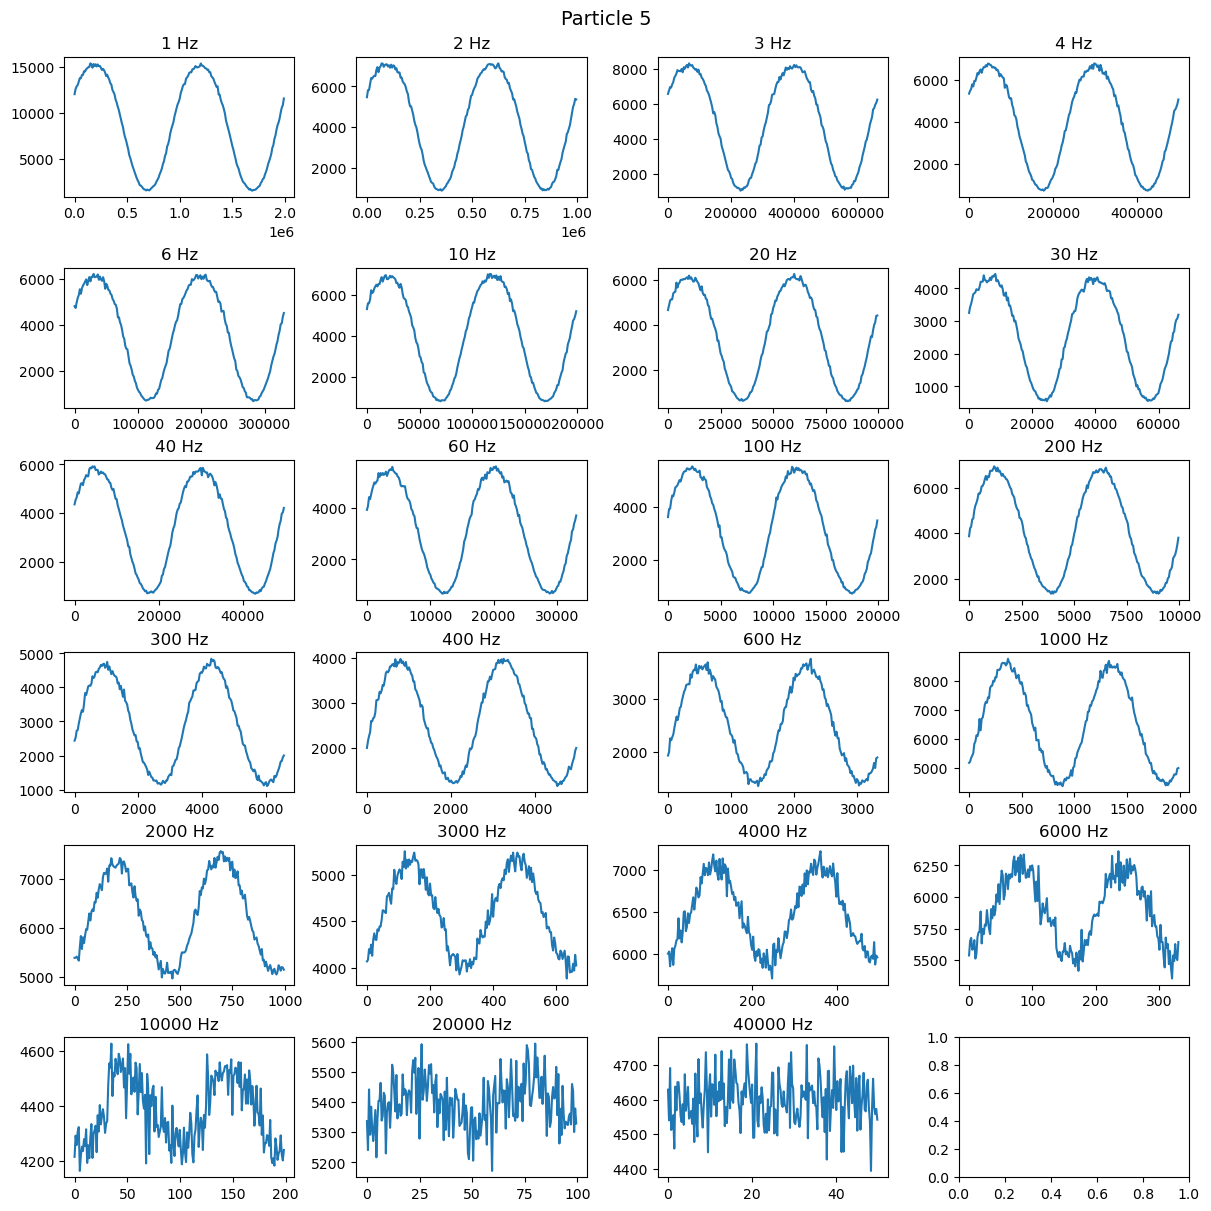


  Processing particle 6  


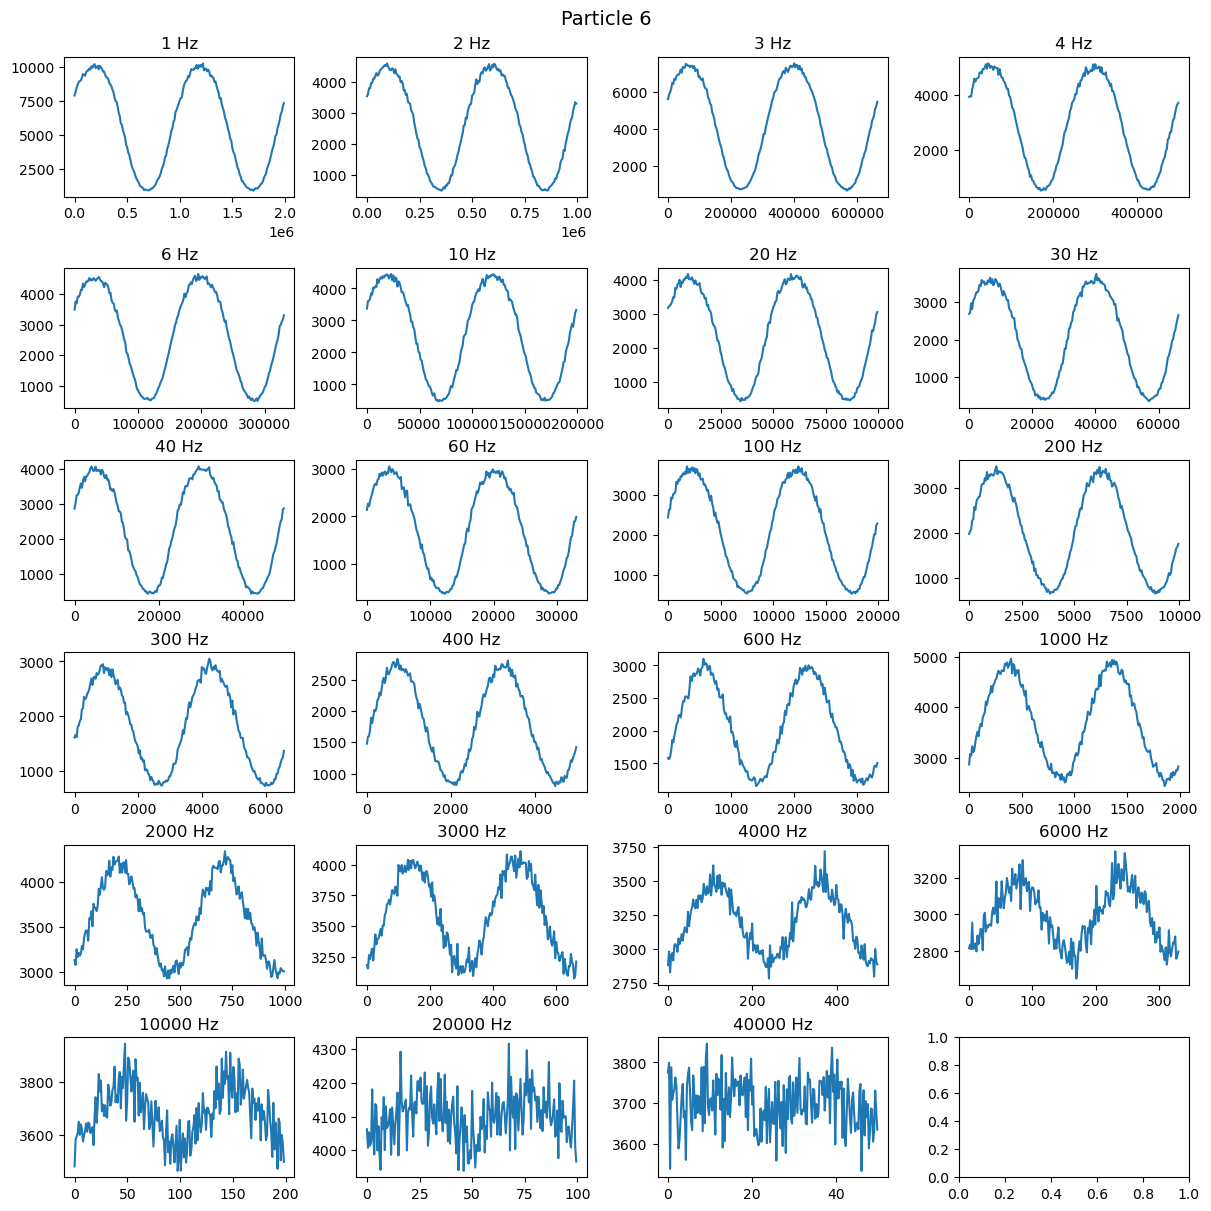


  Processing particle 7  


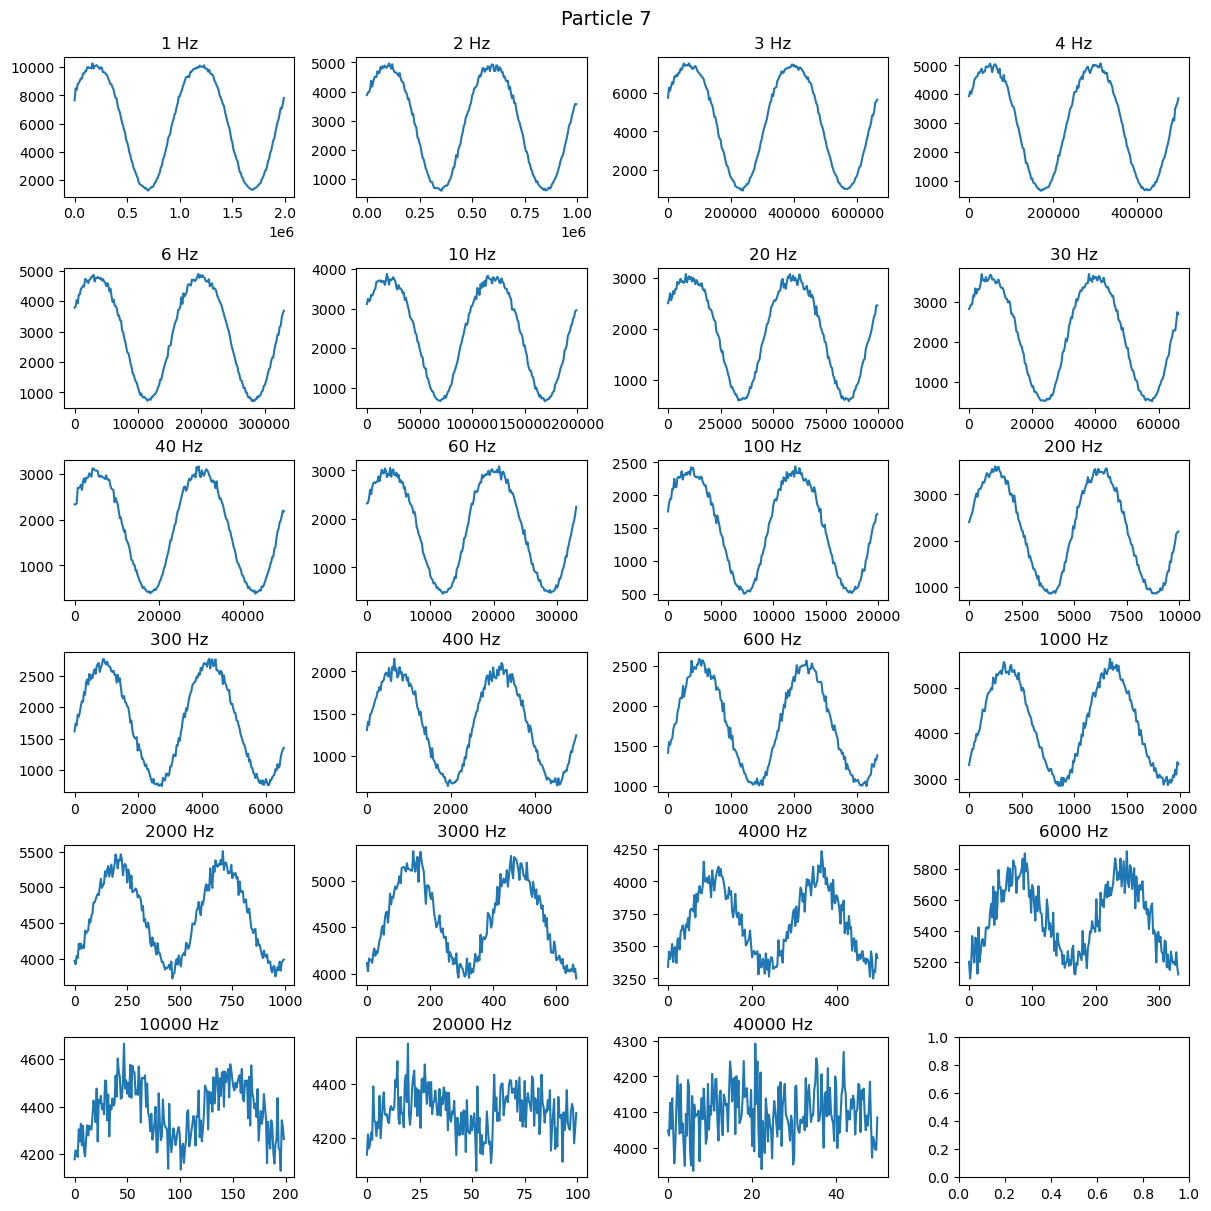


  Processing particle 8  


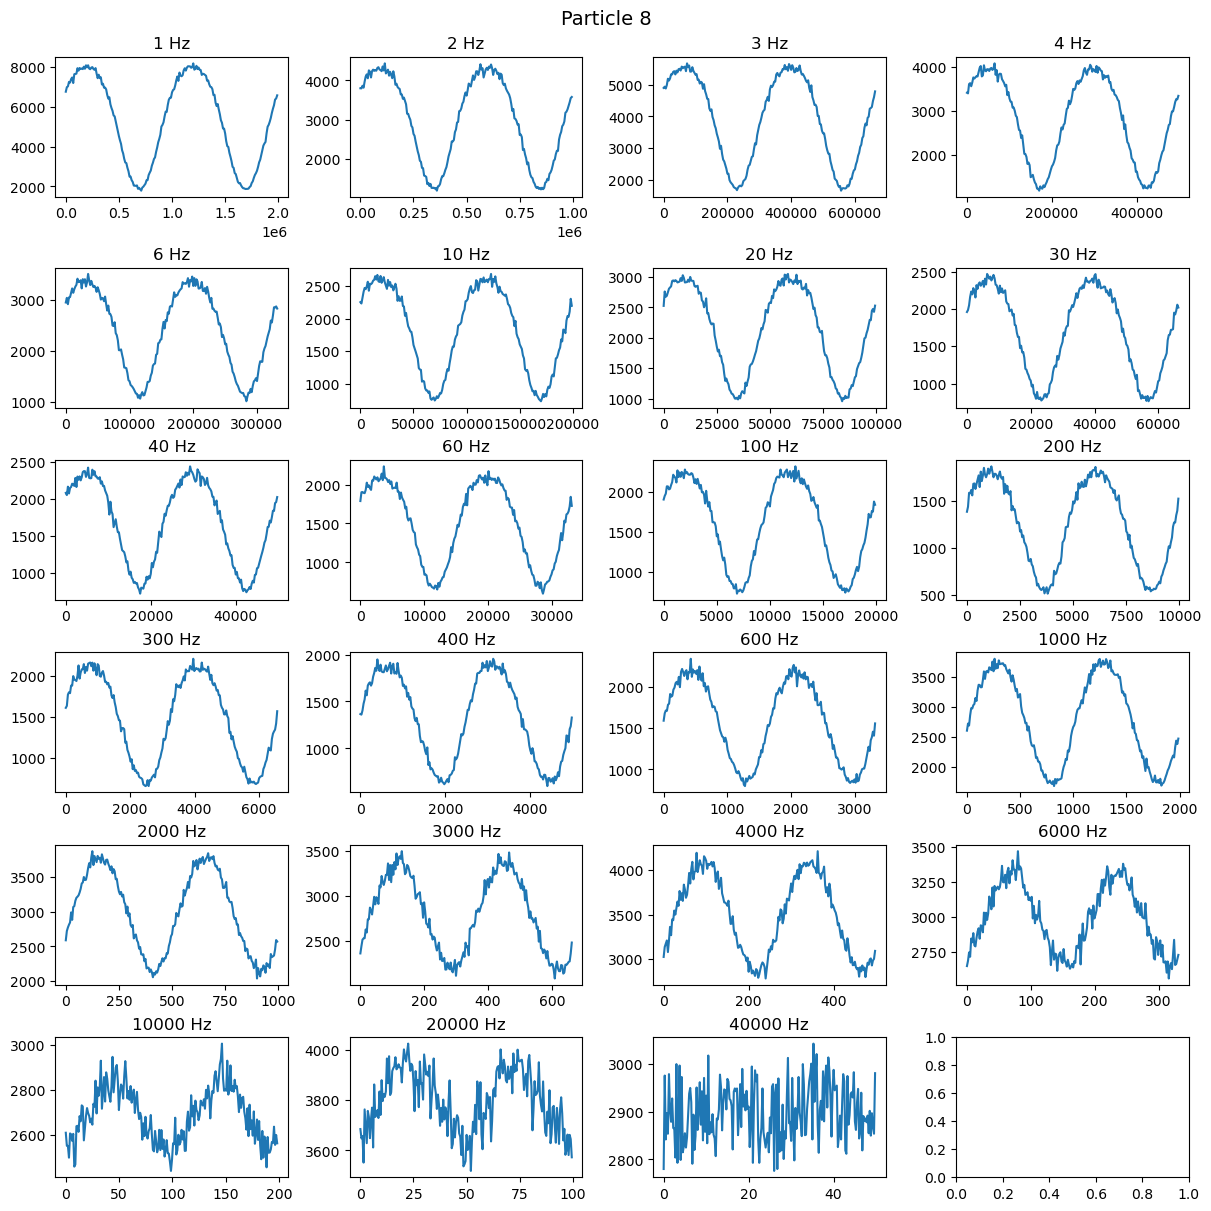


  Processing particle 9  


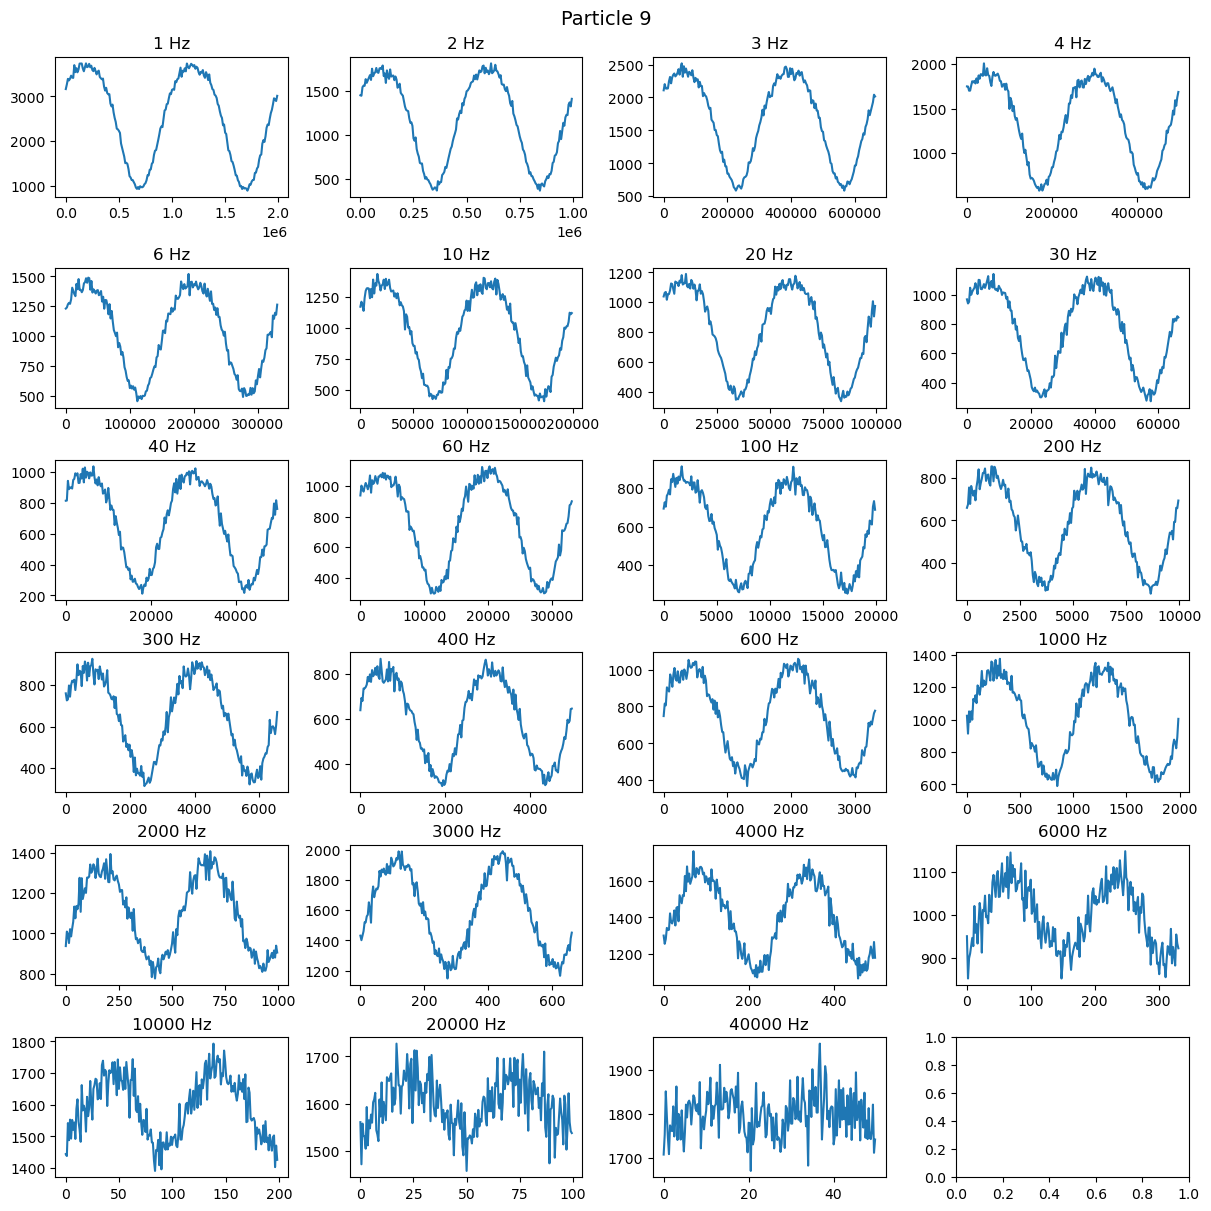


  Processing particle 10  


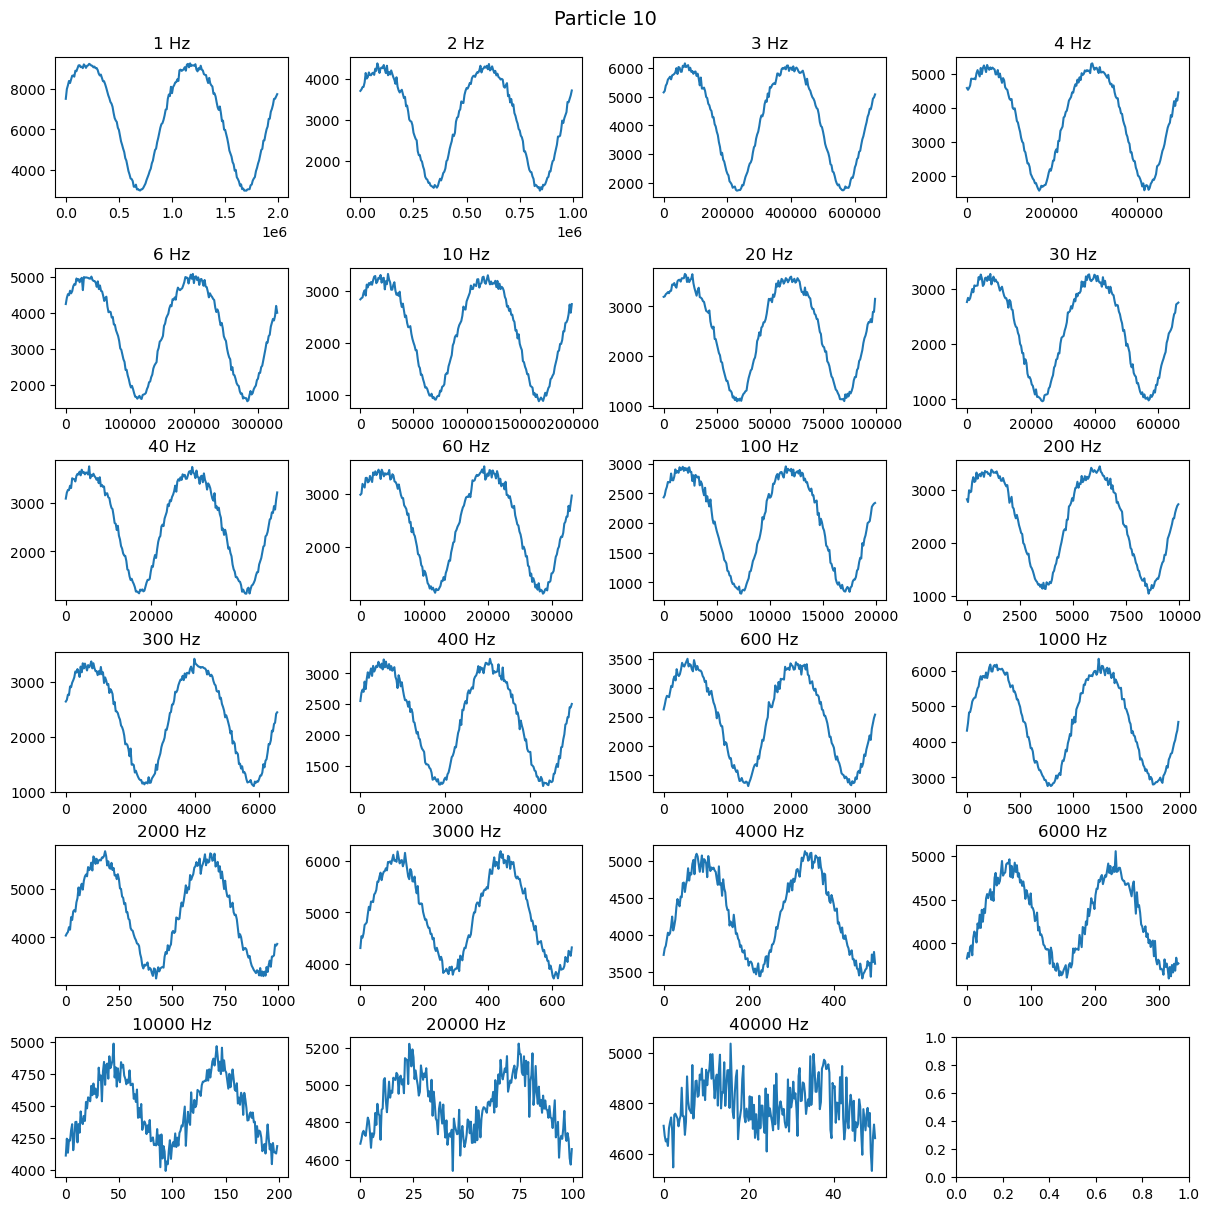

In [33]:
results = []   # armazena resultados de cada partícula

for p_idx, p_dic in enumerate(p_list):
    particle_label = f"Particle {p_dic['p_label']}"
    # correct = adj_phase_correction[p_idx] if p_idx < len(adj_phase_correction) else False

    print(f"\n{'='*50}")
    print(f"  Processing particle {p_dic['p_label']}  ")
    print(f"{'='*50}")

    omegas      = []
    phase_diffs = []

    # ---- Subplots de verificação visual ----
    fig, axs = plt.subplots(rows, cols, figsize=(12, 12), constrained_layout=True)
    fig.suptitle(f"Particle {p_dic["p_label"]}", fontsize=14)

    # data = p_dic["p_data"]

    for index, step_data in enumerate(p_dic["p_data"]):
        freq = step_data["freq"]
        i, j = divmod(index, cols)
        omega = 2 * np.pi * float(freq) * 1e-6
        omegas.append(omega)

        # Colocar para fazer calcular fases média

        ax = axs[i, j]
        # for idx_rep, rep in enumerate(step_data["data"]):
        ax.plot(step_data["data"][:,0], step_data["data"][:,1])
            
        ax.set_title(f"{freq} Hz")
        

    plt.show()

    # # ---- Diferença de fase desta partícula ----
    # omega_arr = np.array(omegas)
    # phase_arr = np.degrees(np.unwrap(np.array(phase_diffs)))

    # plt.scatter(adj_omega(omega_arr), phase_arr)
    # plt.xscale("log")
    # plt.title(f"Phase Difference — {particle_label}")
    # plt.ylabel("Degrees (º)")
    # plt.xlabel("f (Hz)")
    # plt.show()

    # results.append({
    #     "label": particle_label,
    #     "omegas": omega_arr,
    #     "phases": phase_arr,
    #     })

## Get FFT

In [45]:
def populate_fft_info_array(data):
    fund_freq_info_array = []
    
    for idx, dic in enumerate(data):
        # if idx != 3:
        #     continue
        fund_freq_info_array.append({
            "freq": dic["freq"],
            "fft_data": []
        })
    
        # for rep_idx, rep in enumerate(dic["data"]):
        xs_lum, ys_lum = shorten_points(
            np.column_stack((dic["data"][:,0], dic["data"][:,1])), 
            # num_points_off=(10, 20)
        )
            # if dic["freq"]==1000: 
            #     plt.plot(xs_lum, ys_lum)
            #     plt.show()
            
        fund_freq_info_array[-1]["fft_data"].append(
            get_fund_freq_and_amp(xs_lum, ys_lum)
            )
        
        fft_data_arr = np.array(fund_freq_info_array[-1]["fft_data"])
        fund_phases = np.angle(fft_data_arr[:,1])
        fund_freq_info_array[-1]["fund_phases"] = fund_phases
    
    return np.array(fund_freq_info_array)

In [46]:
#Populating the FFT lists
exc_fft_info = populate_fft_info_array(exc_data_npy)

p_fft_info_list = [
    {
        "p_label": p["p_label"],
        "p_fft_info": populate_fft_info_array(p["p_data"])
    }
    for p in p_list
    ]

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [62]:
[p_data["freq"] for p_data in p_fft_info_list[0]["p_fft_info"]]

[1,
 2,
 3,
 4,
 6,
 10,
 20,
 30,
 40,
 60,
 100,
 200,
 300,
 400,
 600,
 1000,
 2000,
 3000,
 4000,
 6000,
 10000,
 20000,
 40000]

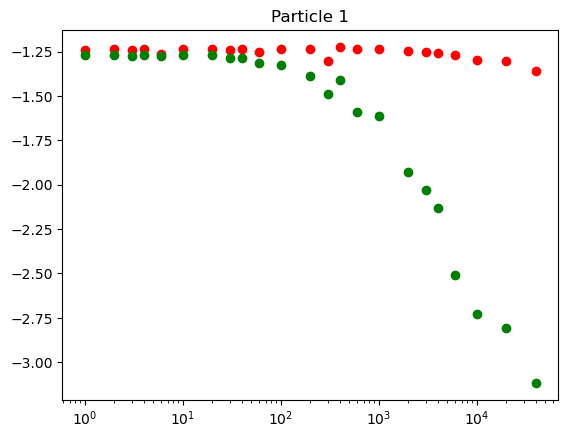

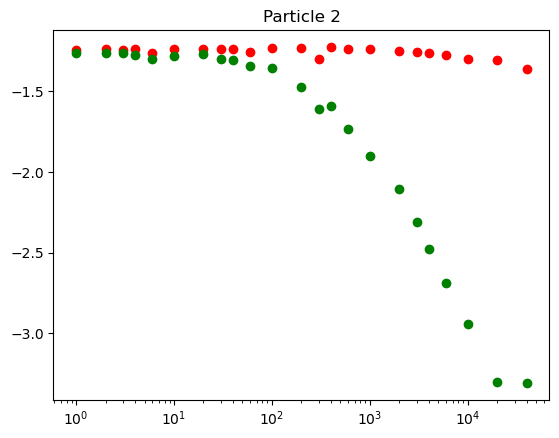

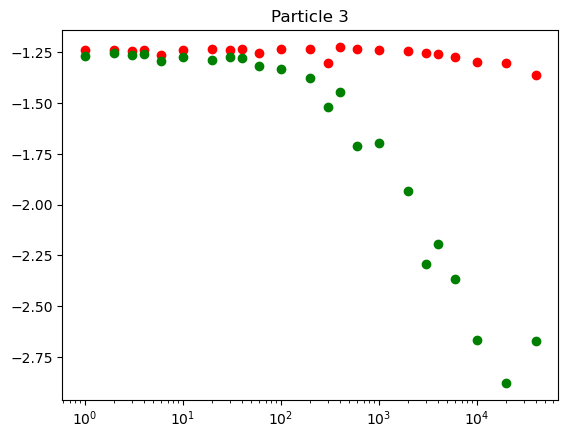

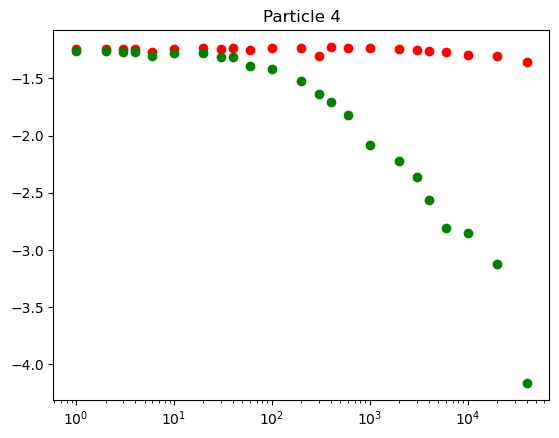

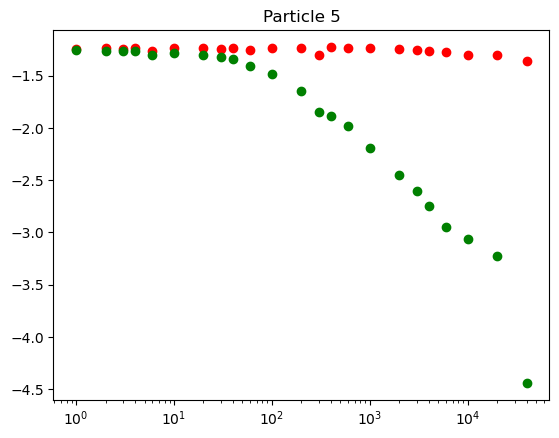

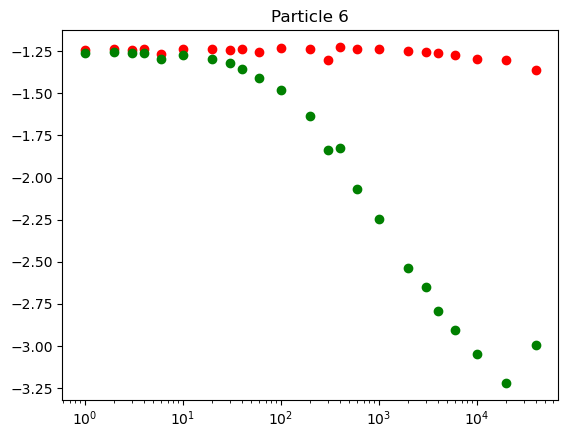

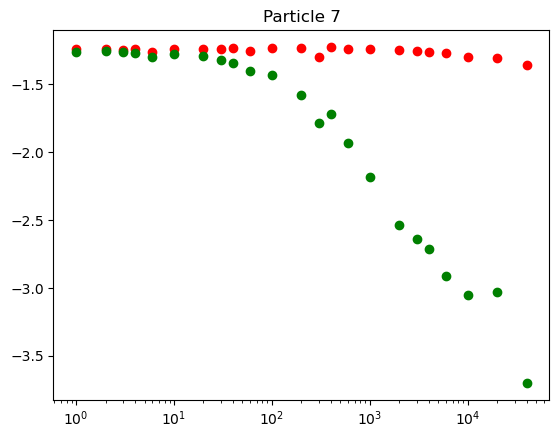

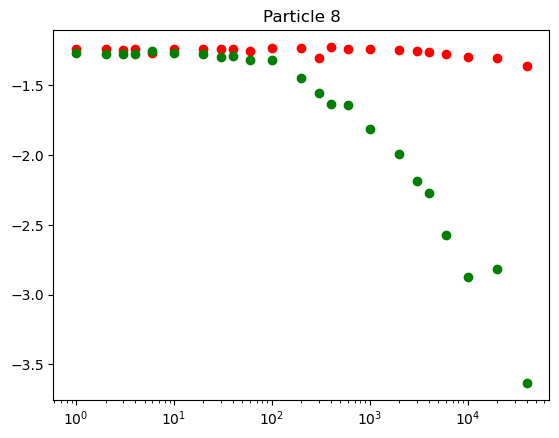

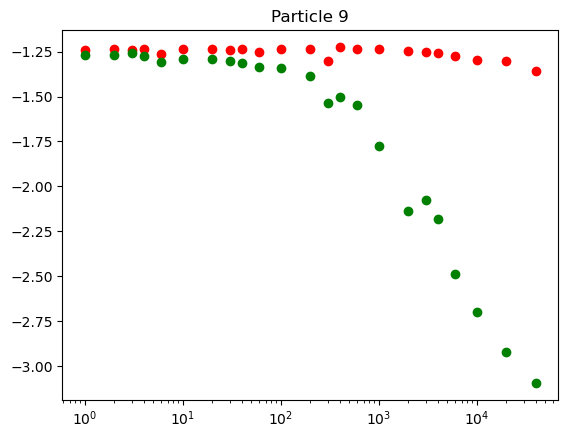

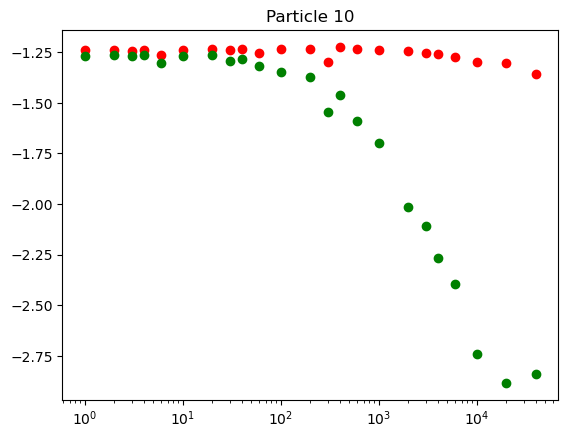

In [68]:

for p_id in range(len(p_fft_info_list)):
    # p_id = 0

    plt.scatter(
        [freq_data["freq"] for freq_data in exc_fft_info],
        np.unwrap(np.array(
            [freq_data["fund_phases"] for freq_data in exc_fft_info]
        ))
        , color="r")

    plt.scatter(
        [p_data["freq"] for p_data in p_fft_info_list[p_id]["p_fft_info"]],
        np.unwrap(np.array(
            [p_data["fund_phases"][0] for p_data in p_fft_info_list[p_id]["p_fft_info"]]
            )),
        color="g")

    plt.title(f"Particle {p_fft_info_list[p_id]["p_label"]}")
    plt.xscale("log")
    plt.show()

## Comparação — todas as partículas

In [ ]:
def get_mean_phase(fft_info_array, particles_list=False):
    if particles_list:
        for p in p_fft_info_list:
            for freq_data in p["p_fft_info"]:
                mean_p = freq_data["fund_phases"].mean()
                std_p = freq_data["fund_phases"].std()
                freq_data["mean_phase"] = mean_p
                freq_data["std_phase"] = std_p

    else:
        for freq_data in fft_info_array:
            mean_p = freq_data["fund_phases"].mean()
            std_p = freq_data["fund_phases"].std()
            freq_data["mean_phase"] = mean_p
            freq_data["std_phase"] = std_p

get_mean_phase(exc_fft_info)
get_mean_phase(p_fft_info_list, particles_list=True)

In [ ]:
def get_error_bar(exc_fft_info_array, p_fft_info_array):
    #  = []_data in exc_fft_info:
    if False:
        exc_mean_p = [
            {
                "freq": step_data["freq"],
                "mean": step_data["mean_phase"],
                "mean_std": step_data["std_phase"]/np.sqrt(len(step_data["fund_phases"])),
            }
            for step_data in exc_fft_info_array
        ]

        for p in p_fft_info_array:
            p["mean_info"] = [
                {
                    "freq": step_data["freq"],
                    "mean": step_data["mean_phase"],
                    "mean_std": step_data["std_phase"]/np.sqrt(len(step_data["fund_phases"]))
                }
                for step_data in p["p_fft_info"]
            ]

            if len(p["mean_info"]) != len(exc_mean_p): 
                print("Verificar tamanhos!")
                return None

            p["error_bar"] = []
            for freq_id, freq_data in enumerate(exc_mean_p):
                p["error_bar"].append({
                    "freq": freq_data["freq"] if freq_data["freq"] == p["mean_info"][freq_id]["freq"] else None,
                    "mean_pd": p["mean_info"][freq_id]["mean"]-freq_data["mean"], 
                    "mean_std_pd": np.sqrt(p["mean_info"][freq_id]["mean_std"]**2+freq_data["mean_std"]**2), 
                })
    
    exc_mean_p = np.array([
            [step_data["freq"], step_data["mean_phase"], step_data["std_phase"]/np.sqrt(len(step_data["fund_phases"]))]
            for step_data in exc_fft_info_array
        ])

    for p in p_fft_info_array:
        p["mean_info"] = np.array([
            [step_data["freq"], step_data["mean_phase"], step_data["std_phase"]/np.sqrt(len(step_data["fund_phases"]))]
            for step_data in p["p_fft_info"]
        ])

        end_points_off = -2
        _, axs = plt.subplots(1,2, figsize=(15,5))
        axs[0].scatter(exc_mean_p[:end_points_off,0], exc_mean_p[:end_points_off,1], color="r")
        axs[0].scatter(p["mean_info"][:end_points_off,0], p["mean_info"][:end_points_off,1], color="g")
        axs[0].set_title(f"Particle {p["p_label"]}")
        axs[0].set_xscale("log")

        axs[1].scatter(exc_mean_p[:end_points_off,0], exc_mean_p[:end_points_off,1], color="r")
        axs[1].scatter(p["mean_info"][:end_points_off,0], 
                       np.unwrap(p["mean_info"][:end_points_off,1]), 
                       color="g")
        axs[1].set_title(f"Particle {p["p_label"]} - unwrapped")
        axs[1].set_xscale("log")
        plt.show()

        if len(p["mean_info"]) != len(exc_mean_p):
            print("Verificar tamanhos!")
            return None
        lum_mean_arr = np.unwrap(p["mean_info"][:,1])
        exc_mean_arr = np.unwrap(exc_mean_p[:,1])
        pd_mean_arr = lum_mean_arr - exc_mean_arr
        pd_std_arr = np.hypot(p["mean_info"][:,2], exc_mean_p[:,2])

        p["error_bar"] = np.column_stack((p["mean_info"][:,0], pd_mean_arr, pd_std_arr))
    

get_error_bar(exc_fft_info, p_fft_info_list)

In [ ]:
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for p_id, p in enumerate(p_fft_info_list):
    # if p_id !=1: break
    color = colors[p_id % len(colors)]
    # p["error_bar"]
    for idx, error_point in enumerate(p["error_bar"]):
        if (error_point[0] > 10000): continue
        plt.errorbar(
            error_point[0],
            error_point[1],
            yerr=error_point[2],
            label=f"Particle {p["p_label"]}",
            fmt='o',
            capsize=5,
            color=color,
        )
    plt.title(f"Particle {p['p_label']}  - phase difference")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Phase diferrence (rad)")
    plt.xscale("log")
    plt.show()